<a href="https://colab.research.google.com/github/romidj/CS50-course/blob/main/TP_Etudiants_Classification_Feuille.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP — Classification de feuilles (**lisse vs dentée**) avec PyTorch

**Objectif** : construire pas à pas un classifieur d'images binaire (feuille *lisse* vs *dentée*) avec PyTorch.
Vous implémenterez :
1) le chargement des données avec `ImageFolder` et un **split stratifié** train/val/test,  
2) un **CNN** simple,  
3) une **boucle d'entraînement** + **évaluation** complète,  
4) les **métriques** (accuracy, precision, recall, f1, log-loss, AUC-ROC),  
5) les figures : **matrice de confusion**, **courbe ROC**, **Precision–Recall**.

> Placez vos images dans un dossier structuré :  
`data/feuilles/`  
├── `dentee/` (ou `dentee`)  
└── `lisse/`  
(Chaque sous-dossier contient des images `.jpg/.png`.)

Les cellules marquées `# TODO` sont à **compléter**.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Unzip data.zip
!unzip "/content/drive/MyDrive/data/feuilles_plantes.zip" -d "/content/"

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: /content/feuilles_plantes/dente/rubus035_1.jpg  
  inflating: /content/feuilles_plantes/dente/ulmus090_6.jpg  
  inflating: /content/feuilles_plantes/dente/ulmus008_3.jpg  
  inflating: /content/feuilles_plantes/dente/rubus001_12.jpg  
  inflating: /content/feuilles_plantes/dente/rubus083_11.jpg  
  inflating: /content/feuilles_plantes/dente/castarea006_11.jpg  
  inflating: /content/feuilles_plantes/dente/ulmus068_12.jpg  
  inflating: /content/feuilles_plantes/dente/castarea091_6.jpg  
  inflating: /content/feuilles_plantes/dente/castarea071_3.jpg  
  inflating: /content/feuilles_plantes/dente/ulmus066_17.jpg  
  inflating: /content/feuilles_plantes/dente/castarea034_3.jpg  
  inflating: /content/feuilles_plantes/dente/rubus008_1.jpg  
  inflating: /content/feuilles_plantes/dente/castarea012_0.jpg  
  inflating: /content/feuilles_plantes/dente/rubus054_13.jpg  
  inflating: /content/feuilles_pl

In [3]:
# 🔧 Imports & configuration
import os, random, math, time
from dataclasses import dataclass
from typing import Tuple, List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             balanced_accuracy_score, cohen_kappa_score,
                             log_loss, roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
                             ConfusionMatrixDisplay)

# Reproductibilité
torch.manual_seed(0); random.seed(0); np.random.seed(0)

# Device (GPU si dispo)
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
device


device(type='cuda')

## 1) Données & Transformations

1. Définissez le chemin `DATA_DIR` vers votre dossier `data/feuilles`.
2. Créez des **transformations** pour l'entraînement et la validation/test (redimensionnement, normalisation).
3. Chargez le dataset avec `datasets.ImageFolder`.


In [4]:
# === TODO: chemin de vos données ===
DATA_DIR = "/content/feuilles_plantes"
# classes attendues: ['dentee', 'lisse'] (ordre peut varier selon ImageFolder)

# === TODO: transformations (train/val-test) ===
transform_train = transforms.Compose([
     transforms.Resize((224,224)),
     transforms.RandomHorizontalFlip(),
     transforms.ToTensor(),
     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
transform_eval = transforms.Compose([
     transforms.Resize((224,224)),
     transforms.ToTensor(),
     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      ])


full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform_train)  # pour train; on basculera la transform sur subsets
num_classes = len(full_dataset.classes)
print("Classes détectées:", full_dataset.classes)


Classes détectées: ['dente', 'lisse']


## 2) Split **stratifié** train/val/test

Complétez la fonction `stratified_split` qui répartit équitablement les indices par classe (ex: 70%/15%/15%).

In [5]:
@dataclass
class Splits:
    train: Subset
    val: Subset
    test: Subset

def stratified_split(dataset: datasets.ImageFolder,
                     train_ratio: float = 0.7,
                     val_ratio: float = 0.15,
                     test_ratio: float = 0.15,
                     seed: int = 0) -> Splits:
    """
    Retourne des Subsets train/val/test en respectant la proportion par classe.
    """
    #the sum must be 1
    assert math.isclose(train_ratio + val_ratio + test_ratio, 1.0), "Ratios must sum to 1"
    # TODO:
    # - regrouper les indices par label
    indices_per_class = {label: [] for label in range(len(dataset.classes))}
    for idx, (_, label) in enumerate(dataset):
        indices_per_class[label].append(idx)

    # - mélanger avec une RNG locale seedée , RNG stands for générateur aléatoire seedé pour la reproductibilité
    rng = np.random.RandomState(seed)
    for label in indices_per_class:
        rng.shuffle(indices_per_class[label])

    # - couper selon les ratios
    train_indices, val_indices, test_indices = [], [], []
    for label, indices in indices_per_class.items():
        n = len(indices)
        train_end = int(n * train_ratio)
        val_end = train_end + int(n * val_ratio)

        train_indices.extend(indices[:train_end])
        val_indices.extend(indices[train_end:val_end])
        test_indices.extend(indices[val_end:])
    # - concaténer les indices de toutes les classes
    train_subset = Subset(dataset, train_indices)
    val_subset = Subset(dataset, val_indices)
    test_subset = Subset(dataset, test_indices)

    return Splits(train=train_subset, val=val_subset, test=test_subset)

# === TODO: créer les subsets + DataLoaders ===
splits = stratified_split(full_dataset, 0.7, 0.15, 0.15, seed=0)
# # Important: utiliser transform_eval pour val/test
full_dataset.transform = transform_train
train_loader = DataLoader(splits.train, batch_size=32, shuffle=True, num_workers=2)
full_dataset.transform = transform_eval
val_loader = DataLoader(splits.val, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(splits.test, batch_size=64, shuffle=False, num_workers=2)


## 3) Modèle — CNN simple

Implémentez un CNN compact (2–3 blocs Conv2d→ReLU→MaxPool, puis Linear).

In [6]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 28 * 28, 128)  # Adapter la taille après pooling (224/8=28 si 3 pools)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)  # Logits
        return x

model = SmallCNN(num_classes).to(device)
model

SmallCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=50176, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
  (relu): ReLU()
)

## 4) Boucle d'entraînement + évaluation intermédiaire

Écrivez `train_one_epoch` (entraînement) et `evaluate` (sans gradient) qui renvoient les pertes et les prédictions pour calculer des **métriques**.

In [13]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for imgs, labels in loader:
        imgs = imgs.to(device); labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    y_true, y_pred, y_proba = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(device); labels = labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)

        probs = F.softmax(outputs, dim=1) # Proba classe 1 (dentee, assumez idx 1)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_proba.extend(probs.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(y_true), np.array(y_pred), np.array(y_proba)

# === Entraînement principal ===
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 50
patience = 5  # stop if no improvement after 5 epochs
best_val_loss = float('inf')
counter = 0

for epoch in range(num_epochs):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, y_t, y_p, y_s = evaluate(model, val_loader, criterion)

    print(f"Epoch {epoch:02d} | train {tr_loss:.4f} | val {va_loss:.4f}")

    # --- Early stopping check ---
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        counter = 0
        # optionally save the best model
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch:02d} (no improvement in {patience} epochs)")
            break


Epoch 00 | train 0.0171 | val 0.9728
Epoch 01 | train 0.0013 | val 1.1680
Epoch 02 | train 0.0027 | val 1.2085
Epoch 03 | train 0.0002 | val 1.0866
Epoch 04 | train 0.0000 | val 1.1279
Epoch 05 | train 0.0000 | val 1.1501
Early stopping at epoch 05 (no improvement in 5 epochs)


In [17]:
print("Classes:", full_dataset.classes)
print("Unique labels:", np.unique(y_t))


Classes: ['dente', 'lisse']
Unique labels: [0 1]


In [18]:
print(np.array(y_proba).shape)


(981, 2)


## 5) Métriques (val/test) + Figures

Complétez la cellule pour afficher : accuracy, precision, recall, f1, balanced accuracy, kappa, log-loss, AUC-ROC, **classification report**; puis tracer **matrice de confusion**, **ROC**, **PR**.

Test loss         : 1.0199
Accuracy          : 0.8716
Precision         : 0.8981
Recall            : 0.8255
F1                : 0.8603
Balanced Acc      : 0.8697
Cohen's Kappa     : 0.7418
Log-Loss          : 0.9286
AUC-ROC           : 0.9312

Classification report:
               precision    recall  f1-score   support

       dente       0.90      0.83      0.86       470
       lisse       0.85      0.91      0.88       511

    accuracy                           0.87       981
   macro avg       0.87      0.87      0.87       981
weighted avg       0.87      0.87      0.87       981



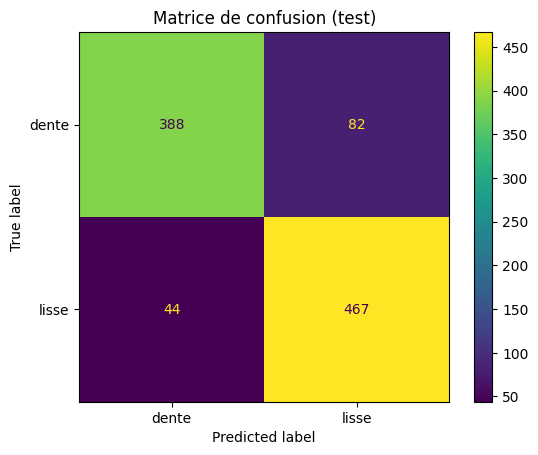

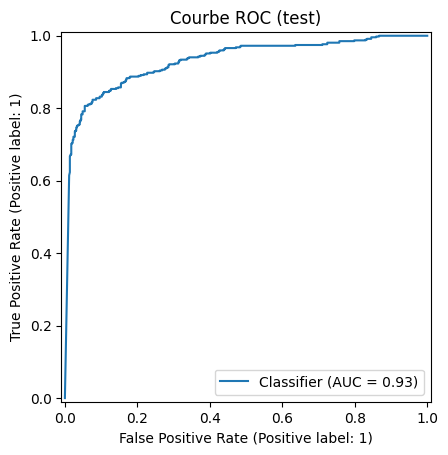

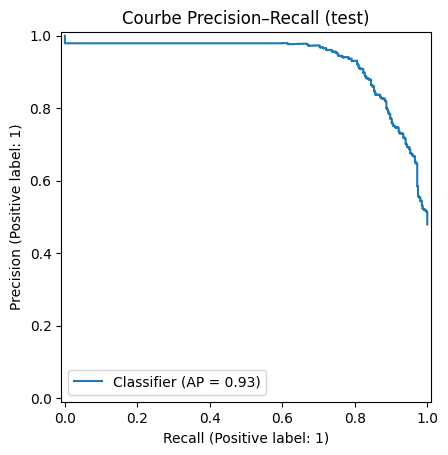

In [29]:
# === Évaluation finale sur test ===
te_loss, y_true, y_pred, y_proba = evaluate(model, test_loader, criterion)  # y_proba: [N, 2]
classes = full_dataset.classes
pos_class_name = "dente"
pos_idx = classes.index(pos_class_name)

# Extraire la proba de la classe positive
y_proba_pos = y_proba[:, pos_idx]  # [N] ← proba de "dentee"

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=pos_idx)
bacc = balanced_accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)

# Log-loss: on donne les probas des 2 classes
ll = log_loss(y_true, y_proba)  # ← y_proba est déjà [N, 2] !

# AUC-ROC: proba de la classe positive
auc = roc_auc_score((y_true == pos_idx).astype(int), y_proba_pos)

print(f"Test loss         : {te_loss:.4f}")
print(f"Accuracy          : {acc:.4f}")
print(f"Precision         : {prec:.4f}")
print(f"Recall            : {rec:.4f}")
print(f"F1                : {f1:.4f}")
print(f"Balanced Acc      : {bacc:.4f}")
print(f"Cohen's Kappa     : {kappa:.4f}")
print(f"Log-Loss          : {ll:.4f}")
print(f"AUC-ROC           : {auc:.4f}")
print("\nClassification report:\n", classification_report(y_true, y_pred, target_names=classes))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=classes).plot(values_format='d')
plt.title("Matrice de confusion (test)")
plt.show()

# ROC
RocCurveDisplay.from_predictions((y_true == pos_idx).astype(int), y_proba_pos)
plt.title("Courbe ROC (test)")
plt.show()

# Precision-Recall
PrecisionRecallDisplay.from_predictions((y_true == pos_idx).astype(int), y_proba_pos)
plt.title("Courbe Precision–Recall (test)")
plt.show()

## 6) Analyse d'erreurs (optionnel)
Affichez quelques **faux positifs** et **faux négatifs**.

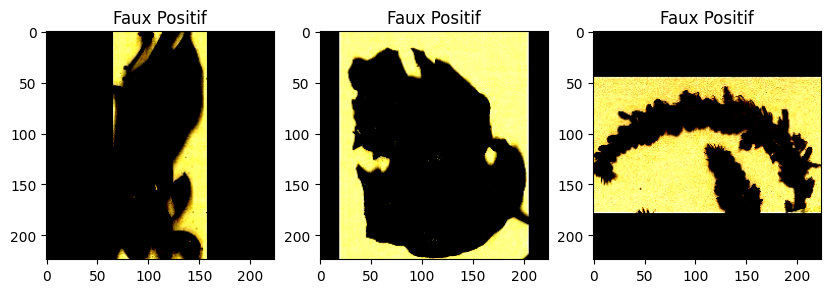

In [30]:
# TODO (optionnel): retrouver des indices d'erreurs et afficher les images correspondantes.
# TODO (optionnel): retrouver des indices d'erreurs et afficher les images correspondantes.
fp_indices = [i for i in range(len(y_true)) if y_pred[i] == pos_idx and y_true[i] != pos_idx]  # Faux positifs
fn_indices = [i for i in range(len(y_true)) if y_pred[i] != pos_idx and y_true[i] == pos_idx]  # Faux négatifs

# Afficher 3 FP
fig, axs = plt.subplots(1, 3, figsize=(10, 3))
for j, idx in enumerate(fp_indices[:3]):
    img, _ = splits.test[idx]  # Image tensor
    axs[j].imshow(img.permute(1, 2, 0).numpy())  # Denormalize si besoin
    axs[j].set_title("Faux Positif")
plt.show()

# Similaire pour FN